In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("loan.csv")

In [3]:
df

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved
...,...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770,Approved
57,25,Female,Receptionist,High School,Single,32000,570,Denied
58,43,Male,Banker,Bachelor's,Married,95000,760,Approved
59,30,Female,Writer,Master's,Single,55000,650,Approved


* For five number summary we use .describe() function

In [4]:
df.describe()

,age,income,credit_score
count,61.000000,61.000000,61.000000
mean,37.081967,78983.606557,709.836066
std,8.424755,33772.025802,72.674888
min,24.000000,25000.000000,560.000000
25%,30.000000,52000.000000,650.000000
50%,36.000000,78000.000000,720.000000
75%,43.000000,98000.000000,770.000000
max,55.000000,180000.000000,830.000000


* To know the datatype of any column we use .info() function

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


* To Know the unique elements in any column we use .unique() function

In [6]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [7]:
df["occupation"].unique()

array(['Engineer', 'Teacher', 'Student', 'Manager', 'Accountant', 'Nurse',
       'Lawyer', 'Artist', 'IT', 'Doctor', 'Consultant', 'Analyst',
       'Salesman', 'Marketing', 'Architect', 'Designer', 'Pharmacist',
       'Researcher', 'Professor', 'Pilot', 'Receptionist', 'Banker',
       'Writer', 'Chef', 'Veterinarian', 'Sales', 'HR', 'Electrician',
       'Realtor', 'Photographer', 'Editor', 'Programmer', 'Dentist',
       'Musician', 'Psychologist', 'Server', 'Software', 'Stylist'],
      dtype=object)

In [8]:
df["education_level"].unique()

array(["Bachelor's", "Master's", 'High School', "Associate's", 'Doctoral'],
      dtype=object)

In [9]:
df["marital_status"].unique()

array(['Married', 'Single'], dtype=object)

In [10]:
df["loan_status"].unique()

array(['Approved', 'Denied'], dtype=object)

* To Encode the elements of the column for train and test the model and for visualizations we will import LableEncoder and then we use the LableEncoder() function as a value of an object and then we will use fit_transform() function of the LableEncoder() to encode the elements of the columns in int datatype

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

In [13]:
# df["occupation_encoder"] = le.fit_transform(df["occupation"])
df["occupation_encoder"] = le.fit_transform(df["occupation"])
df["education_encoder"] = le.fit_transform(df["education_level"])
df["marital_encoder"] = le.fit_transform(df["marital_status"])
df["loan_encoder"] = le.fit_transform(df["loan_status"])


In [14]:
df

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status,occupation_encoder,education_encoder,marital_encoder,loan_encoder
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved,12,1,0,0
1,45,Female,Teacher,Master's,Single,62000,680,Approved,35,4,1,0
2,28,Male,Student,High School,Single,25000,590,Denied,33,3,1,1
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved,16,1,0,0
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770,Approved,2,4,0,0
57,25,Female,Receptionist,High School,Single,32000,570,Denied,27,3,1,1
58,43,Male,Banker,Bachelor's,Married,95000,760,Approved,4,1,0,0
59,30,Female,Writer,Master's,Single,55000,650,Approved,37,4,1,0


In [15]:
df

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status,occupation_encoder,education_encoder,marital_encoder,loan_encoder
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved,12,1,0,0
1,45,Female,Teacher,Master's,Single,62000,680,Approved,35,4,1,0
2,28,Male,Student,High School,Single,25000,590,Denied,33,3,1,1
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved,16,1,0,0
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770,Approved,2,4,0,0
57,25,Female,Receptionist,High School,Single,32000,570,Denied,27,3,1,1
58,43,Male,Banker,Bachelor's,Married,95000,760,Approved,4,1,0,0
59,30,Female,Writer,Master's,Single,55000,650,Approved,37,4,1,0


* Use .drop(columns="< column name>") to delete the columns

In [16]:
df.drop(columns=["occupation","education_level","marital_status","loan_status"],inplace = True)

In [17]:
df

,age,gender,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder
0,32,Male,85000,720,12,1,0,0
1,45,Female,62000,680,35,4,1,0
2,28,Male,25000,590,33,3,1,1
3,51,Female,105000,780,16,1,0,0
4,36,Male,75000,710,0,1,0,0
...,...,...,...,...,...,...,...,...
56,39,Male,100000,770,2,4,0,0
57,25,Female,32000,570,27,3,1,1
58,43,Male,95000,760,4,1,0,0
59,30,Female,55000,650,37,4,1,0


In [18]:
df["gender_encoder"] = le.fit_transform(df["gender"])

In [19]:
df

,age,gender,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder,gender_encoder
0,32,Male,85000,720,12,1,0,0,1
1,45,Female,62000,680,35,4,1,0,0
2,28,Male,25000,590,33,3,1,1,1
3,51,Female,105000,780,16,1,0,0,0
4,36,Male,75000,710,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
56,39,Male,100000,770,2,4,0,0,1
57,25,Female,32000,570,27,3,1,1,0
58,43,Male,95000,760,4,1,0,0,1
59,30,Female,55000,650,37,4,1,0,0


In [20]:
df.drop(columns = ["gender"], inplace = True)

In [21]:
df

,age,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder,gender_encoder
0,32,85000,720,12,1,0,0,1
1,45,62000,680,35,4,1,0,0
2,28,25000,590,33,3,1,1,1
3,51,105000,780,16,1,0,0,0
4,36,75000,710,0,1,0,0,1
...,...,...,...,...,...,...,...,...
56,39,100000,770,2,4,0,0,1
57,25,32000,570,27,3,1,1,0
58,43,95000,760,4,1,0,0,1
59,30,55000,650,37,4,1,0,0


In [22]:
num = df.select_dtypes(include = ("int64","float64")).columns
for i in num:
    print(f"columns : {i}")
    print(df[i].describe())
    print()

columns : age
count    61.000000
mean     37.081967
std       8.424755
min      24.000000
25%      30.000000
50%      36.000000
75%      43.000000
max      55.000000
Name: age, dtype: float64

columns : income
count        61.000000
mean      78983.606557
std       33772.025802
min       25000.000000
25%       52000.000000
50%       78000.000000
75%       98000.000000
max      180000.000000
Name: income, dtype: float64

columns : credit_score
count     61.000000
mean     709.836066
std       72.674888
min      560.000000
25%      650.000000
50%      720.000000
75%      770.000000
max      830.000000
Name: credit_score, dtype: float64



In [23]:
df

,age,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder,gender_encoder
0,32,85000,720,12,1,0,0,1
1,45,62000,680,35,4,1,0,0
2,28,25000,590,33,3,1,1,1
3,51,105000,780,16,1,0,0,0
4,36,75000,710,0,1,0,0,1
...,...,...,...,...,...,...,...,...
56,39,100000,770,2,4,0,0,1
57,25,32000,570,27,3,1,1,0
58,43,95000,760,4,1,0,0,1
59,30,55000,650,37,4,1,0,0


* Compute the pairwise correlation of columns excluding NA or Null values

In [24]:
corr_matrix = df.corr()

In [25]:
corr_matrix

,age,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder,gender_encoder
age,1.000000,0.743184,0.806042,-0.236898,0.197880,-0.746899,-0.648135,-0.049218
income,0.743184,1.000000,0.937983,-0.342652,0.164035,-0.752035,-0.699577,0.051406
credit_score,0.806042,0.937983,1.000000,-0.347896,0.149835,-0.845532,-0.820765,0.111500
occupation_encoder,-0.236898,-0.342652,-0.347896,1.000000,0.109864,0.397308,0.271510,-0.252175
education_encoder,0.197880,0.164035,0.149835,0.109864,1.000000,-0.043876,-0.232458,-0.024387
marital_encoder,-0.746899,-0.752035,-0.845532,0.397308,-0.043876,1.000000,0.740370,-0.281703
loan_encoder,-0.648135,-0.699577,-0.820765,0.271510,-0.232458,0.740370,1.000000,-0.233413
gender_encoder,-0.049218,0.051406,0.111500,-0.252175,-0.024387,-0.281703,-0.233413,1.000000


<Axes: >

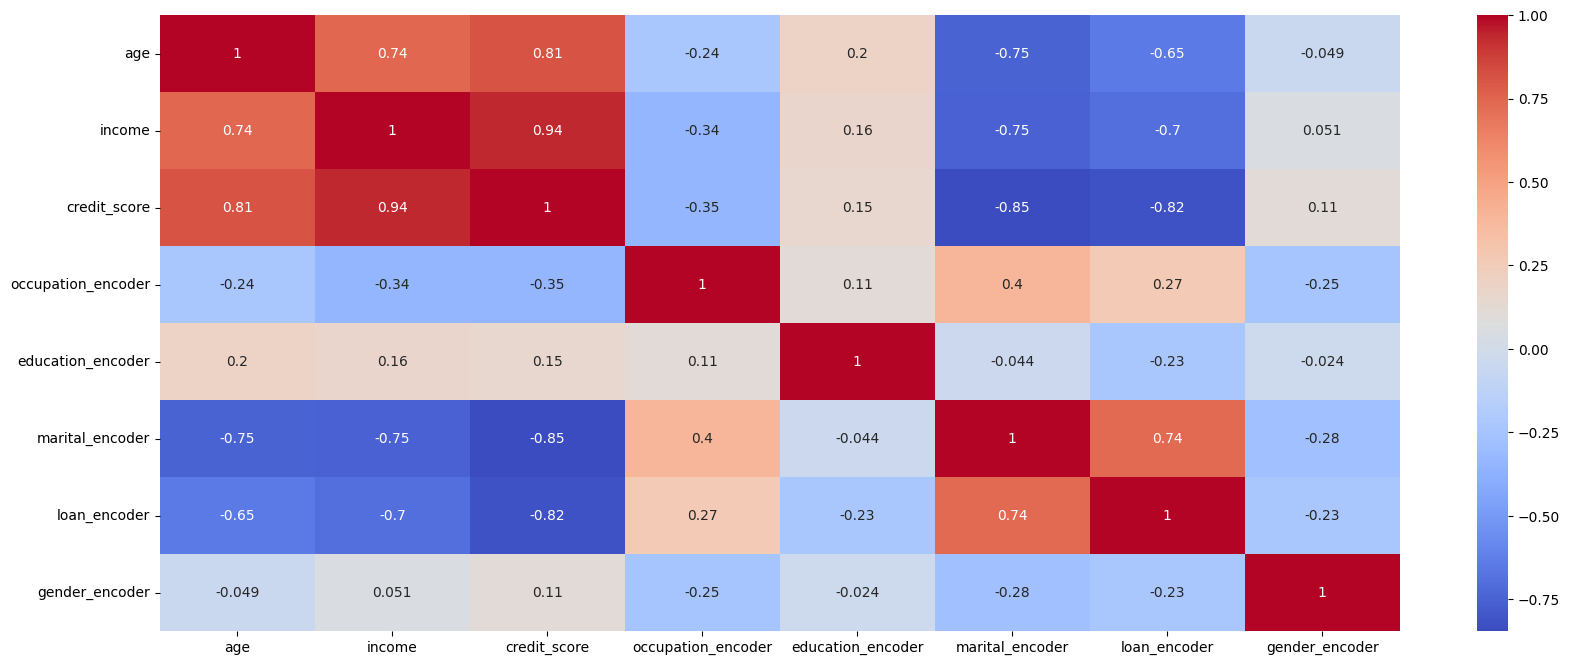

In [26]:
plt.figure(figsize = (20,8))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm")

In [27]:
df

,age,income,credit_score,occupation_encoder,education_encoder,marital_encoder,loan_encoder,gender_encoder
0,32,85000,720,12,1,0,0,1
1,45,62000,680,35,4,1,0,0
2,28,25000,590,33,3,1,1,1
3,51,105000,780,16,1,0,0,0
4,36,75000,710,0,1,0,0,1
...,...,...,...,...,...,...,...,...
56,39,100000,770,2,4,0,0,1
57,25,32000,570,27,3,1,1,0
58,43,95000,760,4,1,0,0,1
59,30,55000,650,37,4,1,0,0


<Axes: xlabel='education_encoder', ylabel='loan_encoder'>

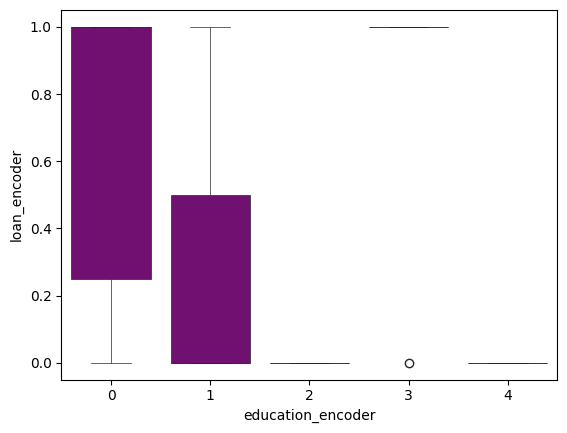

In [28]:
plt.figure()
sns.boxplot(x="education_encoder", y="loan_encoder",data=df, color="Purple", linewidth=0.5)

<Axes: xlabel='occupation_encoder', ylabel='loan_encoder'>

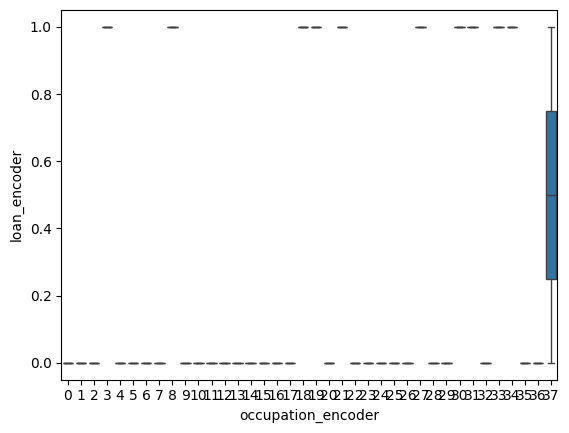

In [29]:
plt.figure()
sns.boxplot(x="occupation_encoder", y="loan_encoder",data=df)

<Axes: xlabel='gender_encoder', ylabel='loan_encoder'>

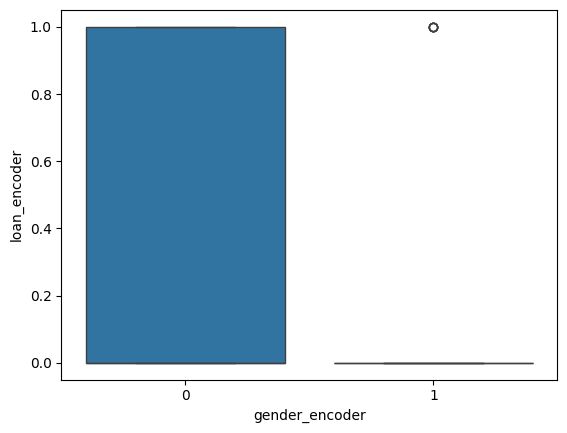

In [30]:
plt.figure()
sns.boxplot(x="gender_encoder", y="loan_encoder",data=df)

<Axes: xlabel='age', ylabel='loan_encoder'>

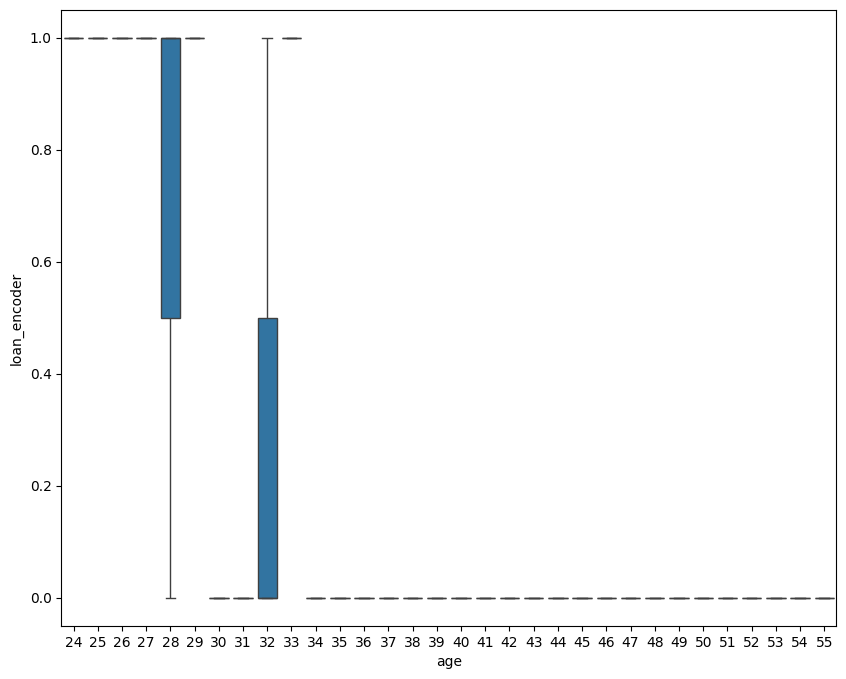

In [31]:
plt.figure(figsize = (10,8))
sns.boxplot(x="age", y="loan_encoder",data=df)

<Axes: xlabel='income', ylabel='loan_encoder'>

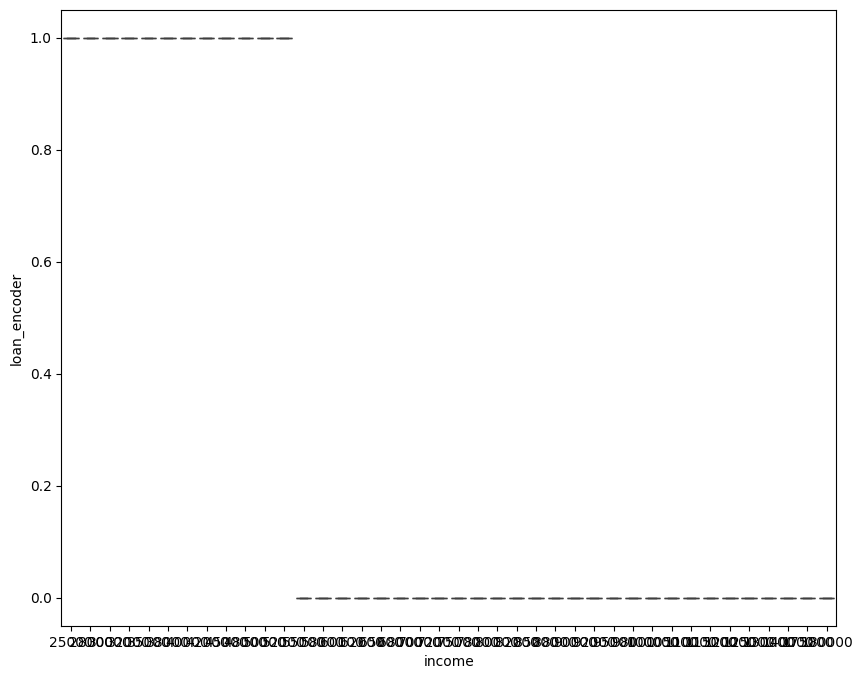

In [32]:
plt.figure(figsize = (10,8))
sns.boxplot(x="income", y="loan_encoder",data=df)

<Axes: xlabel='credit_score', ylabel='loan_encoder'>

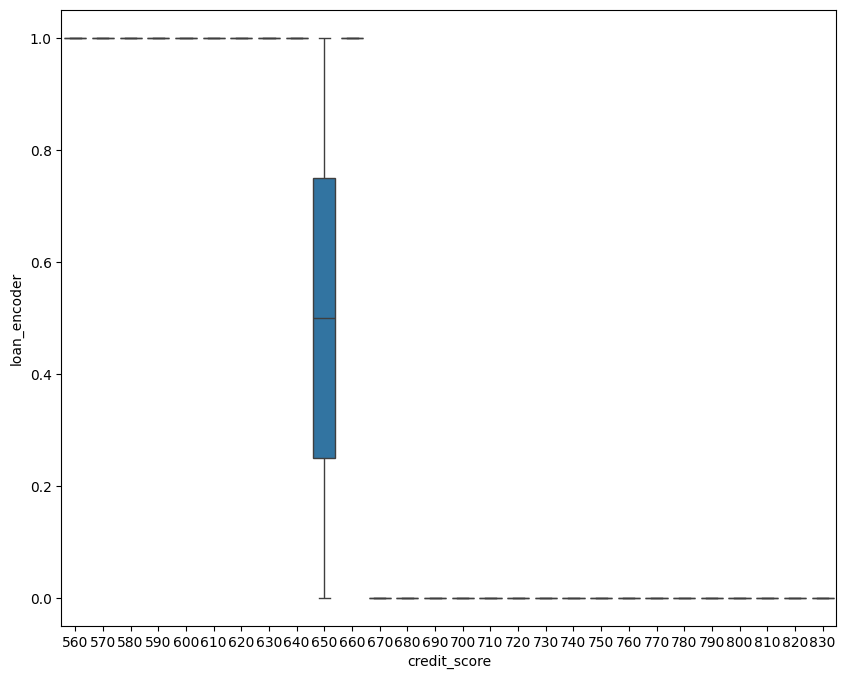

In [33]:
plt.figure(figsize = (10,8))
sns.boxplot(x="credit_score", y="loan_encoder",data=df)

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X = df.drop('loan_encoder',axis=1)
y = df['loan_encoder']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [38]:
# Initialize the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)


LogisticRegression()

In [39]:
# Make predictions on the test data
y_pred = model.predict(X_test)


In [40]:
y_pred

array([0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0])

In [41]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [42]:
# Generate a precision score
ps = precision_score(y_test, y_pred)
print('precision_score:')
print(ps)

precision_score:
1.0


In [43]:
# Generate a precision score
ps = precision_score(y_test, y_pred)
print('precision_score:')
print(ps)

precision_score:
1.0


In [44]:
import pickle

In [ ]:
pickle.dump(model, open("loan_model.pkl", "wb"))

In [46]:
loaded_model = pickle.load(open("loan_model.pkl", "rb"))
loaded_model

LogisticRegression()

In [48]:
loaded_model.predict(X_test)

array([0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0])